# Práctica obligatoria: Clasificación con Regresión Logística (Titanic)
Solución de referencia (para comparar y corregir tu notebook).

**Objetivo:** construir un modelo de **Regresión Logística** para predecir `survived`, evaluar en train/test con métricas de clasificación, matriz de confusión y curva ROC, y hacer un extra de multiclasificación.


## 0) Imports y utilidades

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)

import bootcampviztools as bvt

RANDOM_STATE = 42


## 1) Carga del dataset

In [23]:
df = pd.read_csv("./data/titanic.csv")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2) Limpieza inicial (sin imputar aún)
Aquí **solo** quitamos columnas que no usaremos y revisamos nulos/duplicados. La imputación la haremos más adelante **solo con estadísticas del train**.

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


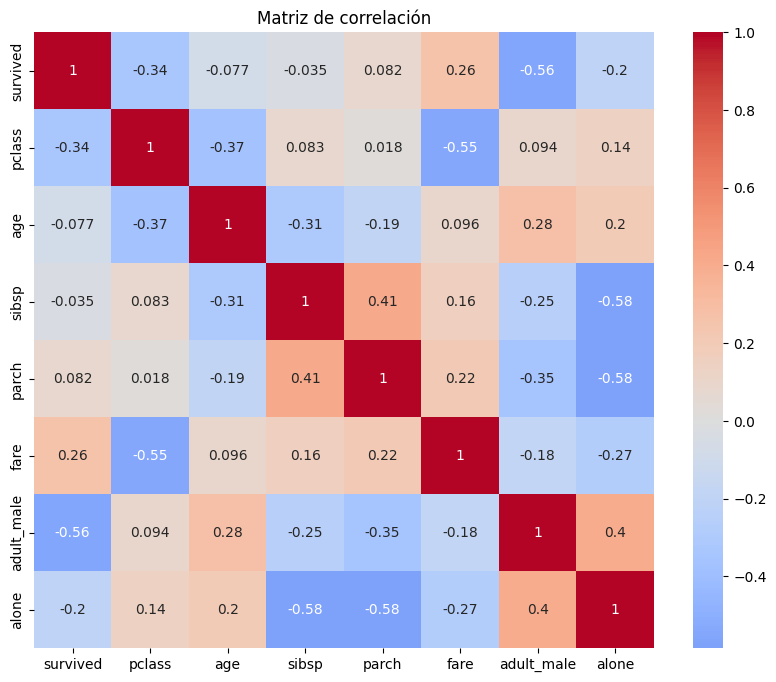

In [25]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0)

plt.title("Matriz de correlación")
plt.show()

In [26]:
# Columnas que suelen ser redundantes o muy derivadas
drop_cols = [
    'class',        # Categórica
    'who',          # Categórica
    'adult_male',   # Categórica 
    'deck',         # Muchísimos nulos
    'embark_town',  # Duplicado de embarked
    'alive'         # Duplicado de survived
]

df_model = df.drop(columns=drop_cols)
df_model.isna().sum()

survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
alone         0
dtype: int64

In [27]:
df.dropna(subset=['embarked'], inplace=True) #embarque es importante, y sólo son 2 filas con ese dato perdido
df_model.dropna(subset=['embarked'], inplace=True)

## 3) EDA rápida orientada al target de ``survived``

In [28]:
df_model['survived'].value_counts(normalize=True)

survived
0    0.617548
1    0.382452
Name: proportion, dtype: float64

(4, 2)


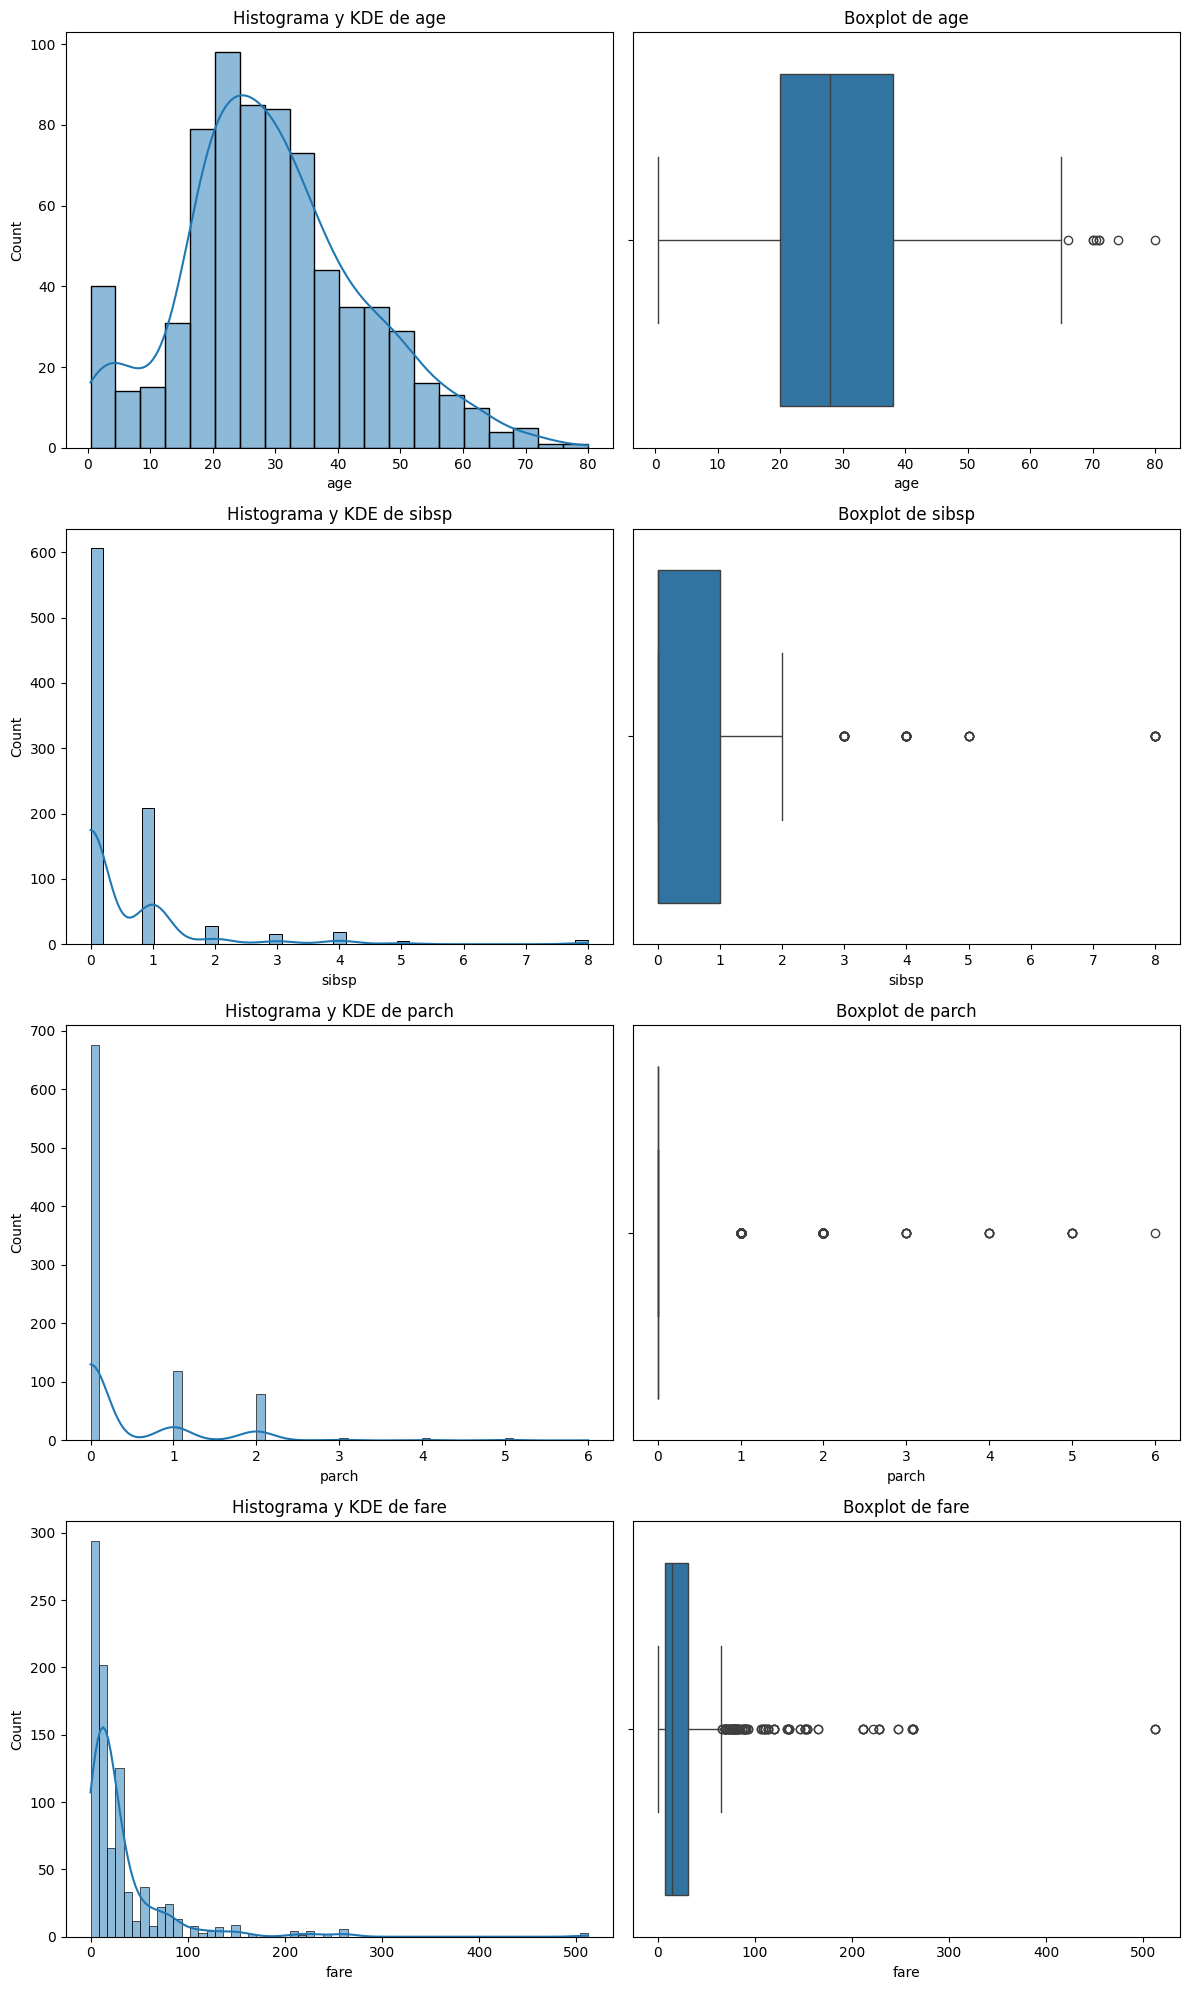

In [29]:
#Variables numéricas
num_cols = ['age', 'sibsp', 'parch', 'fare']
bvt.plot_combined_graphs(df_model, num_cols)

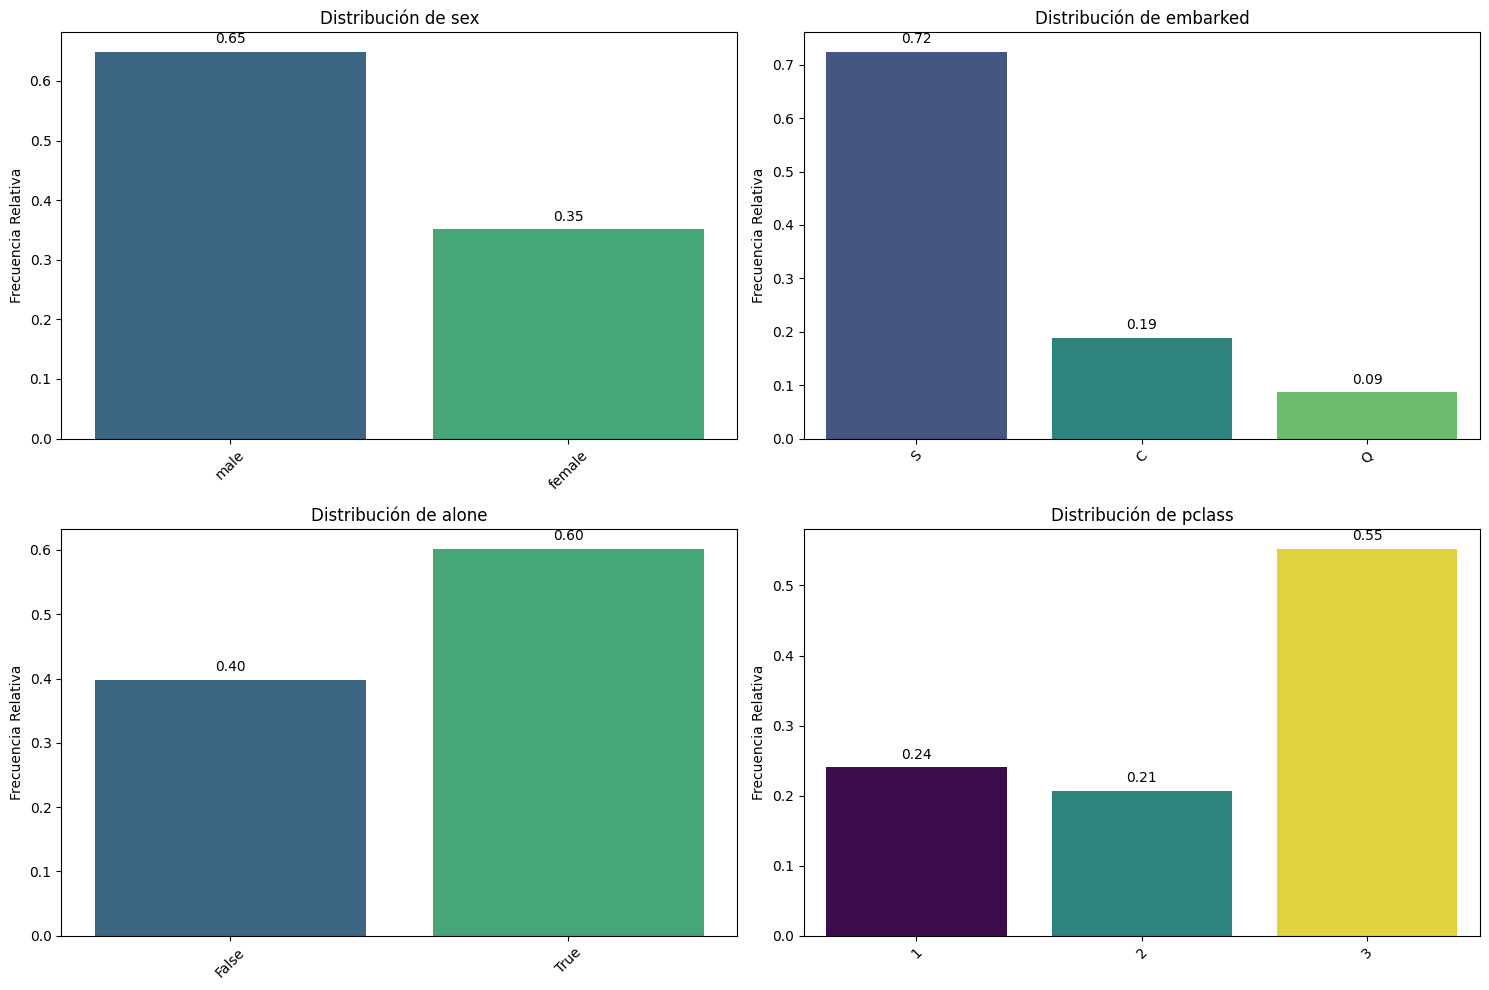

In [30]:
# Variables categóricas
cat_cols = ['sex', 'embarked', 'alone', 'pclass']
bvt.pinta_distribucion_categoricas(df_model, cat_cols, relativa=True, mostrar_valores=True)

## 4) Split train/test cuidando el reparto de `embarked`


In [31]:
train_df, test_df = train_test_split(
    df_model,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_model['embarked']
)

train_df['embarked'].value_counts(normalize=True), test_df['embarked'].value_counts(normalize=True)

(embarked
 S    0.724332
 C    0.188467
 Q    0.087201
 Name: proportion, dtype: float64,
 embarked
 S    0.724719
 C    0.191011
 Q    0.084270
 Name: proportion, dtype: float64)

## 5) Construcción de X/y (train y test)

In [32]:
target = 'survived'
X_train = train_df.drop(columns=[target]).copy()
y_train = train_df[target].copy()

X_test = test_df.drop(columns=[target]).copy()
y_test = test_df[target].copy()

X_train.shape, X_test.shape

((711, 8), (178, 8))

## 6) Imputación manual 
Calculamos medias (numéricas) y modas (categóricas) **en train** y las aplicamos a train/test.

In [33]:
# Separación de columnas
num_features = ['age', 'sibsp', 'parch', 'fare']
cat_features = ['sex', 'embarked', 'alone', 'pclass']


num_impute_values = X_train[num_features].mean(numeric_only=True)
cat_impute_values = {col: X_train[col].mode(dropna=True)[0] for col in cat_features}

num_impute_values, cat_impute_values

(age      29.710454
 sibsp     0.499297
 parch     0.368495
 fare     31.646823
 dtype: float64,
 {'sex': 'male', 'embarked': 'S', 'alone': np.True_, 'pclass': np.int64(3)})

In [34]:
#Aplico la imputación a numéricas y categóricas
X_train[num_features] = X_train[num_features].fillna(num_impute_values)
X_test[num_features]  = X_test[num_features].fillna(num_impute_values)

for col, mode_val in cat_impute_values.items():
    X_train[col] = X_train[col].fillna(mode_val)
    X_test[col]  = X_test[col].fillna(mode_val)

X_train.isna().sum(), X_test.isna().sum()

(pclass      0
 sex         0
 age         0
 sibsp       0
 parch       0
 fare        0
 embarked    0
 alone       0
 dtype: int64,
 pclass      0
 sex         0
 age         0
 sibsp       0
 parch       0
 fare        0
 embarked    0
 alone       0
 dtype: int64)

## 7) Mini-EDA 

In [ ]:
#Sustituyo por la mediana en train y test, que faltaban en ambos

age_median = train_df['age'].median()

train_df['age'] = train_df['age'].fillna(age_median)
test_df['age'] = test_df['age'].fillna(age_median)

In [39]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 711 entries, 46 to 253
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  711 non-null    int64  
 1   pclass    711 non-null    int64  
 2   sex       711 non-null    object 
 3   age       711 non-null    float64
 4   sibsp     711 non-null    int64  
 5   parch     711 non-null    int64  
 6   fare      711 non-null    float64
 7   embarked  711 non-null    object 
 8   alone     711 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(2)
memory usage: 50.7+ KB


In [40]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 178 entries, 223 to 142
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  178 non-null    int64  
 1   pclass    178 non-null    int64  
 2   sex       178 non-null    object 
 3   age       178 non-null    float64
 4   sibsp     178 non-null    int64  
 5   parch     178 non-null    int64  
 6   fare      178 non-null    float64
 7   embarked  178 non-null    object 
 8   alone     178 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(2)
memory usage: 12.7+ KB


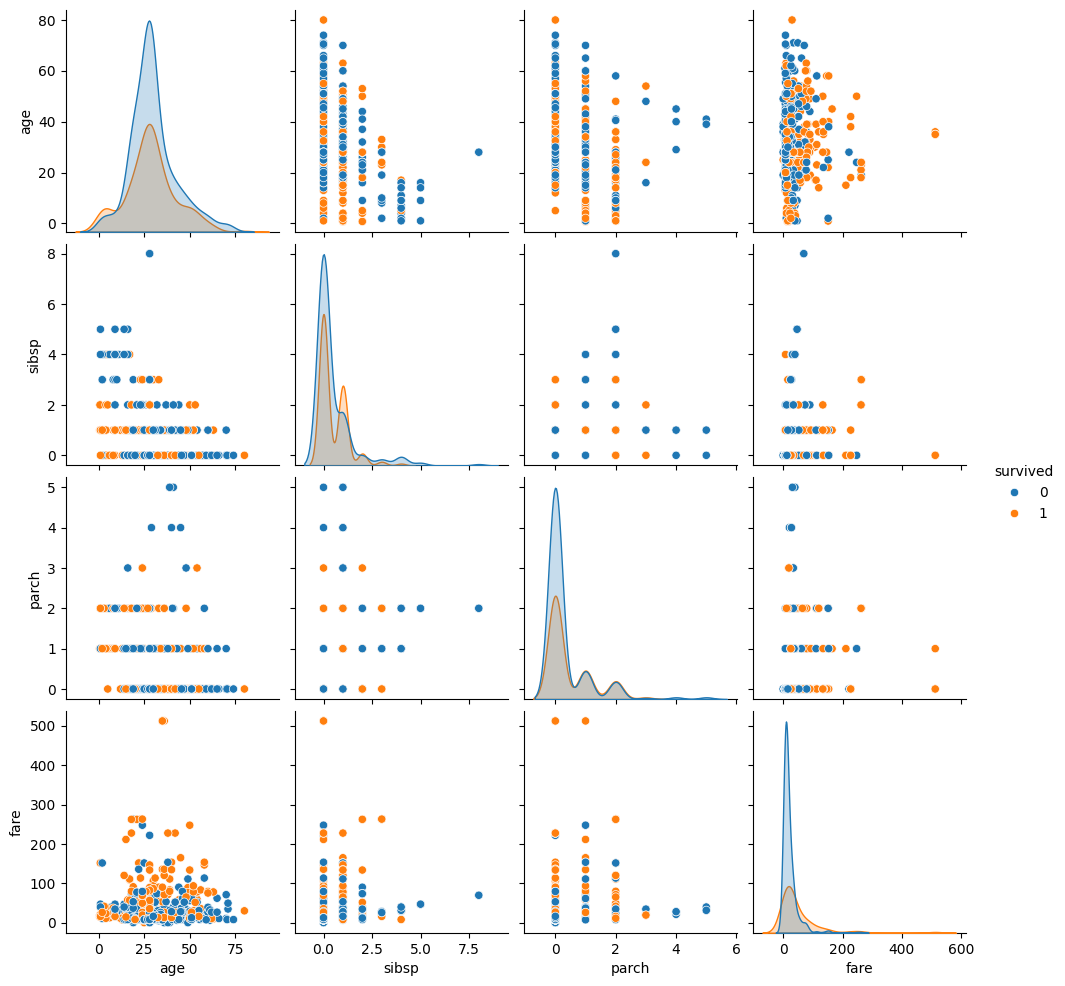

In [45]:
sns.pairplot(train_df[num_cols + [target]], hue = target)

* `fare` muestra una diferencia clara: quienes pagan más tienden a sobrevivir más.
* `age` tiene una ligera influencia (mayor supervivencia en edades bajas), pero no muy marcada.
* `sibsp` y `parch` no separan claramente las clases por sí solos.

En general, las variables numéricas aportan información, pero no generan una separación fuerte entre supervivientes y no supervivientes (fare la que mas)


## 8) Preprocesado 

In [48]:
X_train['sex'] = X_train['sex'].map({'male': 0, 'female': 1})
X_test['sex'] = X_test['sex'].map({'male': 0, 'female': 1})

In [ ]:
X_train = pd.get_dummies(X_train, columns=['embarked'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['embarked'], drop_first=True)

# Asegurar que train y test tengan las mismas columnas
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
X_train.head()

,pclass,sex,age,sibsp,parch,fare,alone,embarked_Q,embarked_S
46,3,0,29.710454,1,0,15.500,False,True,False
230,1,1,35.000000,1,0,83.475,False,False,True
657,3,1,32.000000,1,1,15.500,False,True,False
888,3,1,29.710454,1,2,23.450,False,False,True
809,1,1,33.000000,1,0,53.100,False,False,True


In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['age', 'sibsp', 'parch', 'fare']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


In [53]:
X_train.dtypes, X_test.dtypes


(pclass          int64
 sex             int64
 age           float64
 sibsp         float64
 parch         float64
 fare          float64
 alone            bool
 embarked_Q       bool
 embarked_S       bool
 dtype: object,
 pclass          int64
 sex             int64
 age           float64
 sibsp         float64
 parch         float64
 fare          float64
 alone            bool
 embarked_Q       bool
 embarked_S       bool
 dtype: object)

## 9) Entrenamiento

In [54]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=2000,
    solver='lbfgs'
)

model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [55]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

y_proba_test = model.predict_proba(X_test)[:,1]

## 11) Procesar el datatest de test
Ver que este todo bien 

In [59]:
print("Train shape", X_train.shape)
print("Test shape", X_test.shape)

print("Mismas columnas", all(X_train.columns == X_test.columns))
print("Nulos en test", X_test.isna().sum().sum())


Train shape (711, 9)
Test shape (178, 9)
Mismas columnas True
Nulos en test 0


## 12) Comparación predicción vs real (muestras)

In [60]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

y_proba_test = model.predict_proba(X_test)[:,1]


In [61]:
from sklearn.metrics import classification_report

print("TRAIN\n")
print(classification_report(y_train, y_pred_train))

print("TEST\n")
print(classification_report(y_test, y_pred_test))


TRAIN

              precision    recall  f1-score   support

           0       0.83      0.89      0.86       440
           1       0.79      0.70      0.74       271

    accuracy                           0.81       711
   macro avg       0.81      0.79      0.80       711
weighted avg       0.81      0.81      0.81       711

TEST

              precision    recall  f1-score   support

           0       0.81      0.83      0.82       109
           1       0.72      0.68      0.70        69

    accuracy                           0.78       178
   macro avg       0.76      0.76      0.76       178
weighted avg       0.77      0.78      0.77       178



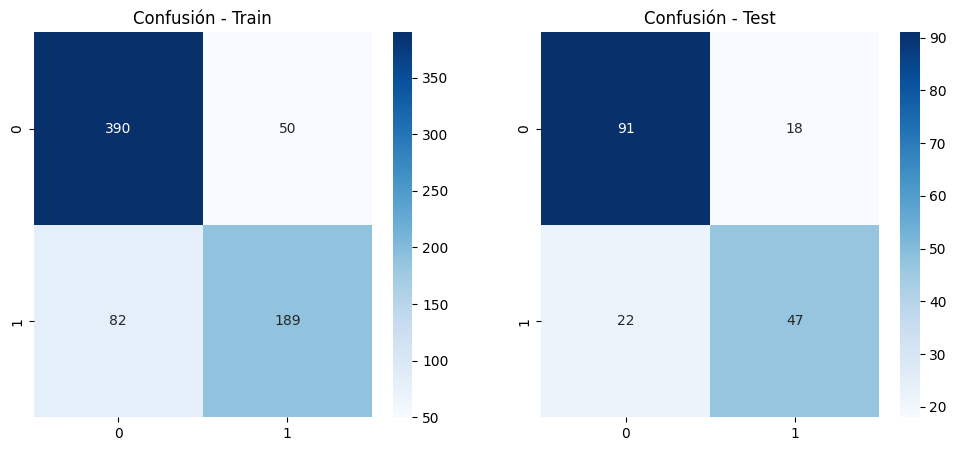

In [62]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_train = confusion_matrix(y_train, y_pred_train)
cm_test = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues')
plt.title("Confusión - Train")

plt.subplot(1,2,2)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues')
plt.title("Confusión - Test")

plt.show()


AUROC: 0.852


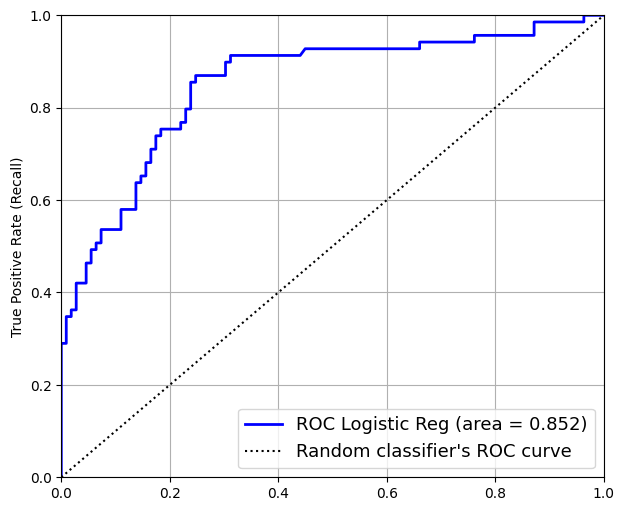

In [79]:
from sklearn.metrics import roc_curve, auc
scores = model.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, scores[:,1])
roc_auc = auc(fpr,tpr)
print("AUROC: %.3f" %(roc_auc))
plt.figure(figsize=(7, 6))  
plt.plot(fpr, tpr, linewidth=2, color= "blue", label=f"ROC Logistic Reg (area = {roc_auc:0.3f})")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.ylabel('True Positive Rate (Recall)')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13)